# Introduction
This Notebook is for ...
Before using this notebook, make sure you already install the updated sagea package via `pip install sagea==0.2.8`

# 1. Downloading files from Zenodo

In [33]:
import pathlib
import urllib.request
import zipfile

url = "https://zenodo.org/records/21422475/files/data_FSC.zip?download=1"
zip_file = pathlib.Path("output_FSC/data_FSC.zip")
extract_dir = pathlib.Path("./")


def format_size(size):
    return size / 1024 / 1024


def download_progress(url, output_path, context=None):
    with urllib.request.urlopen(url, context=context) as response:
        total_size = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        block_size = 1024 * 1024
        bar_width = 40
        with open(output_path, "wb") as f:
            while True:
                block = response.read(block_size)
                if not block:
                    break
                f.write(block)
                downloaded += len(block)
                if total_size > 0:
                    percent = min(downloaded / total_size, 1.0)
                    filled = int(bar_width * percent)
                    bar = "#" * filled + "-" * (bar_width - filled)
                    print(
                        f"\r[{bar}] {percent * 100:6.2f}% "
                        f"{format_size(downloaded):.2f}/{format_size(total_size):.2f} MB",
                        end=""
                    )
                else:
                    print(
                        f"\rdownloading: {format_size(downloaded):.2f} MB",
                        end=""
                    )
    print()


print("starting downloading files...")

# download_progress(url, zip_file)

# use this if there are certificate issues
# import ssl
#
# ssl_context = ssl._create_unverified_context()
# download_progress(
#     url,
#     zip_file,
#     context=ssl_context
# )

print(f"downloading succeed: {zip_file.absolute()}")

print("starting extracting files...")
extract_dir.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(zip_file, "r") as zf:
    zf.extractall(extract_dir)
print(f"extracting succeed: {extract_dir.absolute()}")

starting downloading files...
downloading succeed: /Users/shuhao/PycharmProjects/SaGEA/examples/FSC_filtering/output_FSC/data_FSC.zip
starting extracting files...
extracting succeed: /Users/shuhao/PycharmProjects/SaGEA/examples/FSC_filtering


# 2. read files

In [32]:
import sagea
from sagea.sgio.snx_reader import read_sinex_cov
import numpy as np
import pathlib

"""define file paths"""
path_gfc = pathlib.Path("data_FSC/ITSG-Grace2018_n96_2008-03.gfc")
path_gif48 = pathlib.Path("data_FSC/GIF48.gfc")
path_snx = pathlib.Path("data_FSC/ITSG-Grace2018_n96_2008-03.snx")
path_sig_VCM = pathlib.Path("data_FSC/VCM_Sig_HIS_full_1995_2020_monthly.npy")

"""parameters"""
lmax = 60  # max degree/order

"""read files"""
shc = sagea.SHC.from_gfc(path_gfc, lmax=lmax, key='gfc')
shc_gif48 = sagea.SHC.from_gfc(path_gif48, lmax=lmax, key='gfc')
shc -= shc_gif48

vcm_err, indices = read_sinex_cov(path_snx, lmax=lmax)  # this may take a while, usually several tens of seconds
vcm_sig = np.load(path_sig_VCM)

# 3. FSC filtering processing
FSC filtering based on hybrid prior Bayesian optimal estimation:
$$
\hat{x} = \left( C^{-1} + \beta (\alpha_1 D + \alpha_2 K)^{-1} \right)^{-1} C^{-1} x,
$$
where $x$ and $\hat{x}$ are the unfiltered and filtered sphereical harmonic coefficients (SHCs), $C$ is the error variance-covariance matrix (VCM) estimated as the inverse of normal equations (NEQs), $D$ is the signal VCM estimated from the ensemble of ESA Earth System Model (ESM) models, and $K$ is the Kaula-type diagonal VCM. $\beta$ is an optional experimental scaling factor to further control filtering strength.
Parameters $\alpha_1$ and $\alpha_2$ are calculated using variance compoenent estimation (VCE).

Class `SHC` has built-in FSC filter, using
```python
shc.filter("fsc", vcm_err, vcm_sig_list, **args)
```
Necessary parameters include `vcm_err`for error VCM and `vcm_sig_list` for hybrid signal VCMs.
Other optional parameters include `init_alphas`, `from_degree` and `scale`.
`initial_alphas` is the initial value of iteration, a list, and the same length as vcm_sig.
`from_degree` determines the degree of starting filtering. Considering that GRACE gravity fields generally do not contain degree-0 and -1 terms, the default value of `from_degree` is 2.
`scale` determines the scaling of the final filtering matrix ($\beta$) in the formula. The larger the value, the stronger the filtering intensity, and the more observation noise is suppressed. However, the signal damping/bias also increases accordingly. The default value is 1, which means no scaling after the VCE process.
`inplace` (bool) is a general parameter for shc correction. If true, it changes the value inside the shc instance. Otherwise, it returns a new shc instance.

In [34]:
def generate_kaula_matrix(l_max=60, power=2.):
    degrees = []
    for l in range(l_max + 1):
        num_coefficients = 2 * l + 1
        degrees.extend([l] * num_coefficients)

    degrees = np.array(degrees)
    N = len(degrees)  # 总系数个数 (例如 l_max=60 时，N = 61^2 = 3721)

    kaula_variances = np.zeros(N)

    for i, l in enumerate(degrees):
        if l == 0:
            kaula_variances[i] = 1

        elif l == 1:
            kaula_variances[i] = 1

        else:
            kaula_variances[i] = 1 / (l ** power)

    K = np.diag(kaula_variances)

    return K


vcm_kaula = generate_kaula_matrix(l_max=lmax, power=4)

shc.filter(
    "fsc",
    vcm_err=vcm_err,
    vcm_sig_list=[vcm_sig, vcm_kaula],
    init_alphas=[1, 1],
    from_degree=2,
    scale=1e0,
    inplace=True
)

Starting VCE Iterations...
[VCE] Iter: 034 | Max Diff: 7.7315e-05 | Alphas: [3.63013599e+00 2.66034282e-19]
-> VCE Converged successfully in 34 iterations.


# 4. Spherical harmonic synthesis to grid, plot

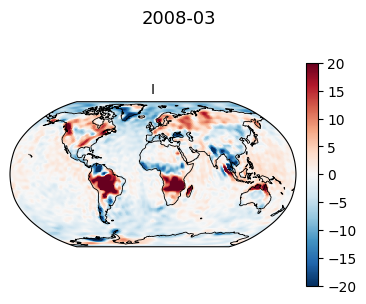

(<Figure size 450x340 with 2 Axes>,
 array([[<GeoAxes: title={'center': 'I'}>]], dtype=object))

In [35]:
import cartopy

grid_space = 1  # degree

shc.convert(from_type="Geopotential", to_type="EWH", inplace=True)  # convert to equivalent water height (EWH, [m])
grid = shc.to_grid(1)

grid.value *= 100  # into unit [cm]
grid.plot(
    index=[0],
    titles="ITSG-Grace2018, FSC filtered",
    title='2008-03',
    gridlines=False,
    vmin=-20, vmax=20,
    projection=cartopy.crs.Robinson()
)